# Breast Cancer Analysis - Tumour Features (Categorical data)

**Warning:** Make sure you have all the following packages installed:

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

import sys
import os

# Get absolute path to "scr"
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

#Importing functions from utils
from utils.view3D import plot_3d_plotly
from utils.Statistics import cohens_d,centroid_dist

# Reading data base

### Database name:
* BC_database_final_version_final.db
### Database structure:
* **df1:** Breast_Cancer_Original
* **df2:** Breast_Cancer_Wisconsin
* **df3:** Breast_Cancer_Metabric
---


# Data Set 1:

## Breast Cancer Wisconsin (Categorical data)

- **Attributes**:
  
  1. Sample code number id number
  2. Clump Thickness 1 - 10
  3. Uniformity of Cell Size 1 - 10
  4. Uniformity of Cell Shape 1 - 10
  5. Marginal Adhesion 1 - 10
  6. Single Epithelial Cell Size 1 - 10
  7. Bare Nuclei 1 - 10
  8. Bland Chromatin 1 - 10
  9. Normal Nucleoli 1 - 10
  10. Mitoses 1 - 10
  11. Class (2 for benign, 4 for malignant)

**Original websites:**
1. https://www.kaggle.com/datasets/mariolisboa/breast-cancer-wisconsin-original-data-set
2. https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [2]:
import sqlite3
import pandas as pd
import os

# Build correct path
db_path = os.path.join("..", "data", "BC_database_final_version.db")

conn = sqlite3.connect(db_path)

df1 = pd.read_sql_query("SELECT * FROM Breast_Cancer_Original", conn)
conn.close()


# Heatmap visualization:

<Axes: >

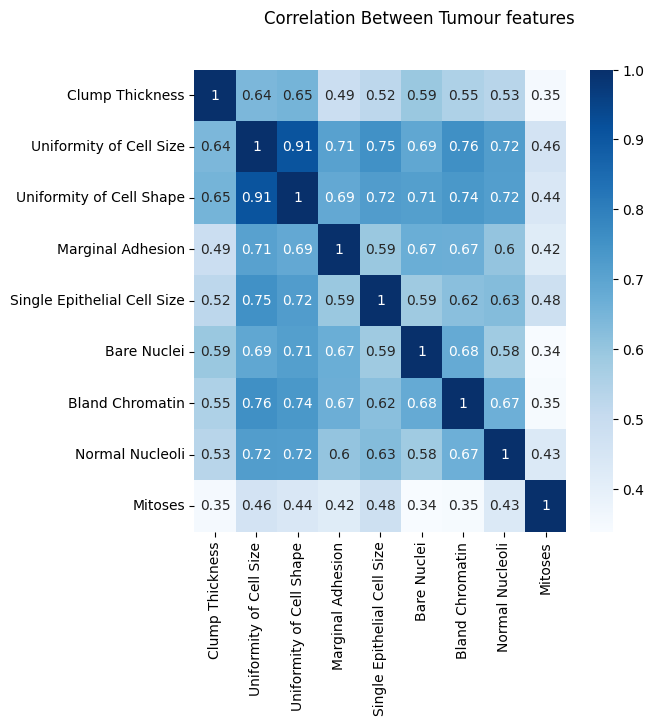

In [3]:
plt.figure(figsize=(6,6))
plt.suptitle("Correlation Between Tumour features")
sns.heatmap(df1.drop(columns=["Sample number","Class"]).corr(),annot=True,cmap="Blues")

# Clustermap visualization:

Visualizing in clusters the highest correlated features (Pearson values over 0.6)

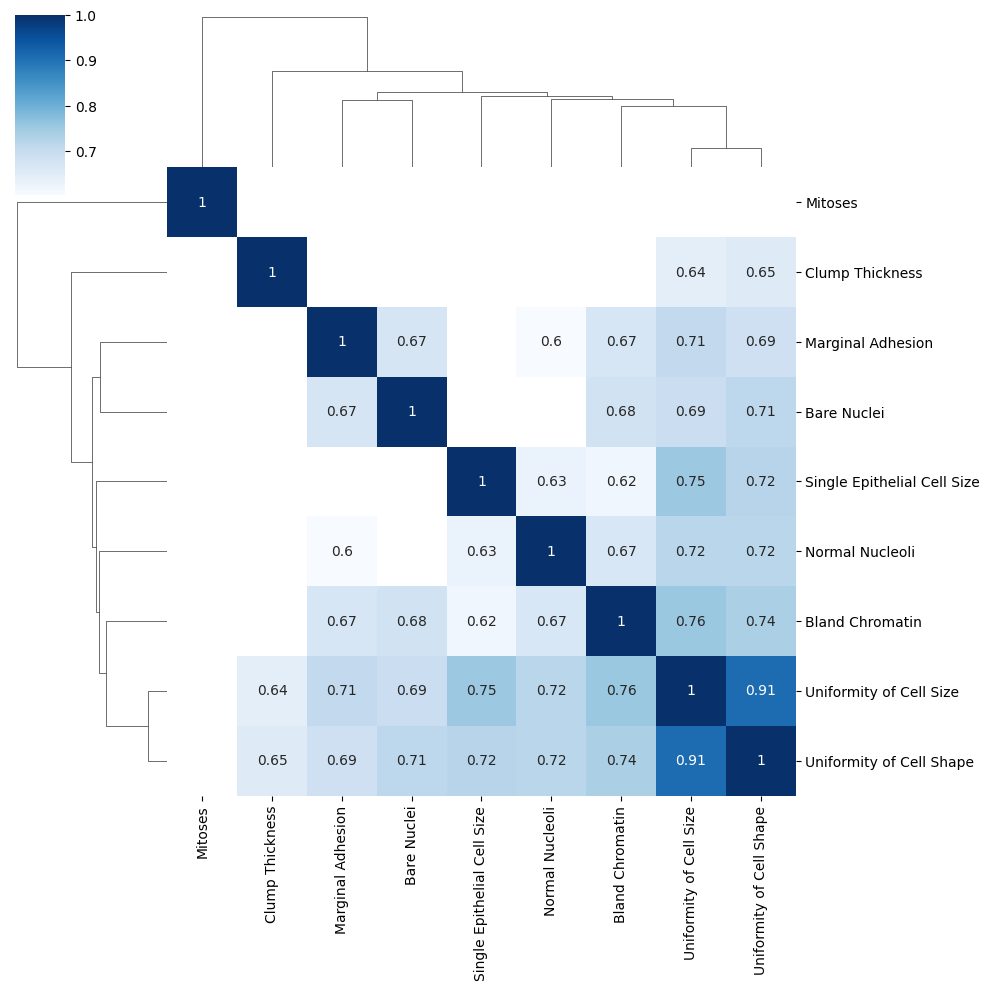

In [4]:
import numpy as np

corr = df1.drop(columns=["Sample number","Class"]).corr()

# Create mask for values <= 0.6
mask = np.abs(corr) < 0.6

sns.clustermap(
    corr,
    annot=True,
    cmap="Blues",
    mask=mask,
)

# Top 6 Highest pairwise Linear correlation:
* Uniformity of Cell Size, Uniformity of Cell Shape, Bland Chromatin, Normal Nucleoli, Single Epithelial Cell Size, Bare Nuclei

# Data Distribution by Diagnosis:

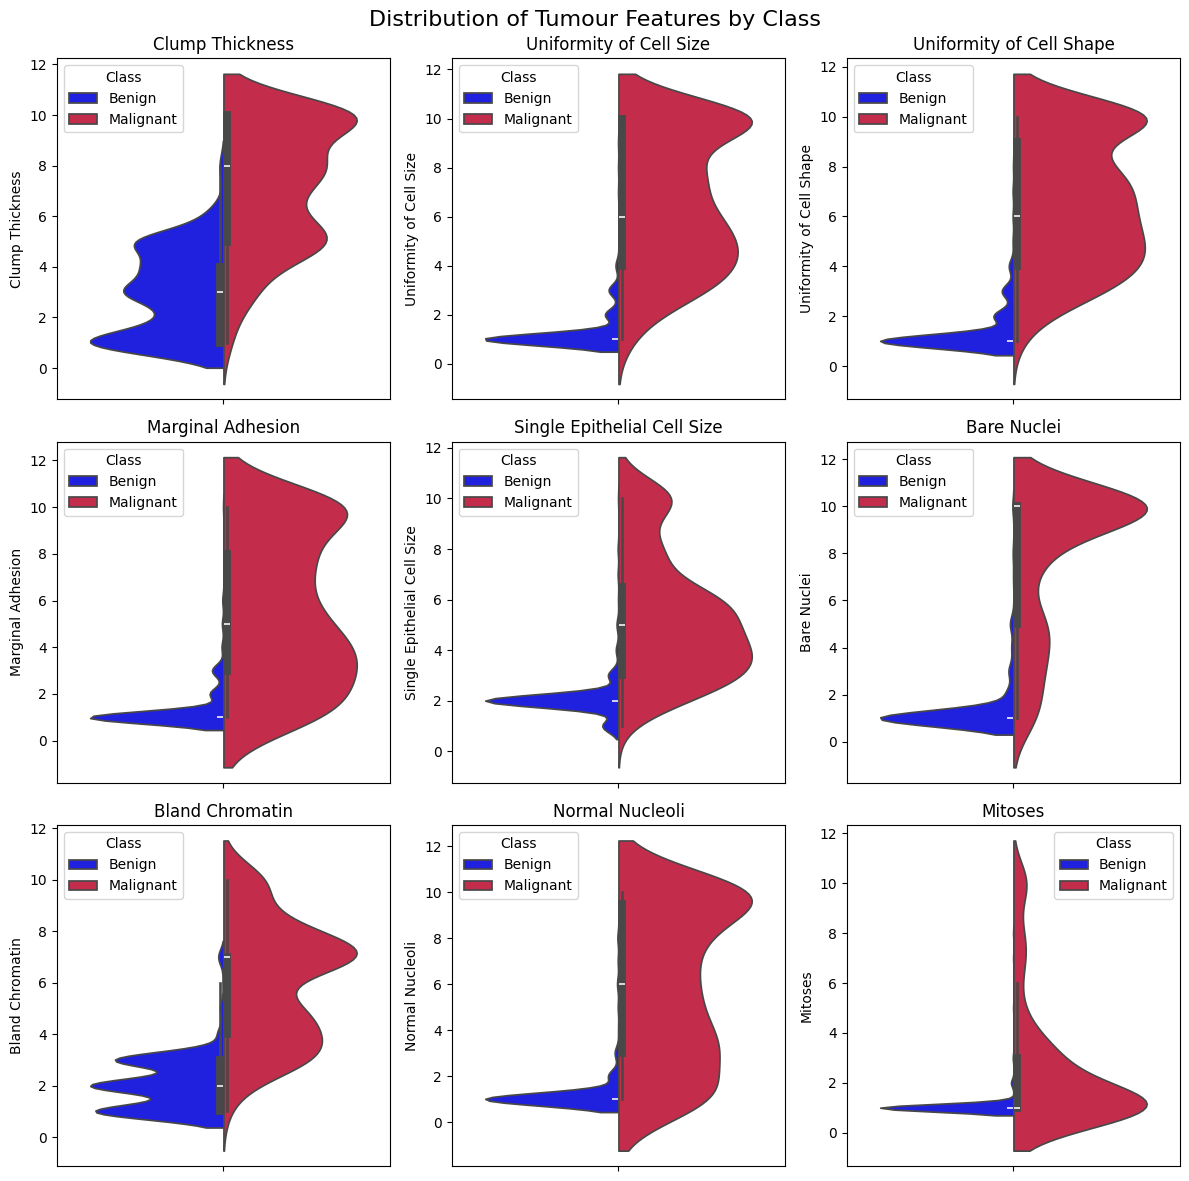

In [5]:
features = list(df1)[1:-1]

plt.figure(figsize=(12,12))

counter = 0
for i in features:
    counter += 1
    plt.subplot(3,3,counter)
    sns.violinplot(
        df1,
        y=i,
        hue="Class",
        split=True,
        palette={"Benign": "blue", "Malignant": "crimson"}  
    )
    plt.title(i)
   

plt.suptitle("Distribution of Tumour Features by Class", fontsize=16)
plt.tight_layout()  #
plt.show()

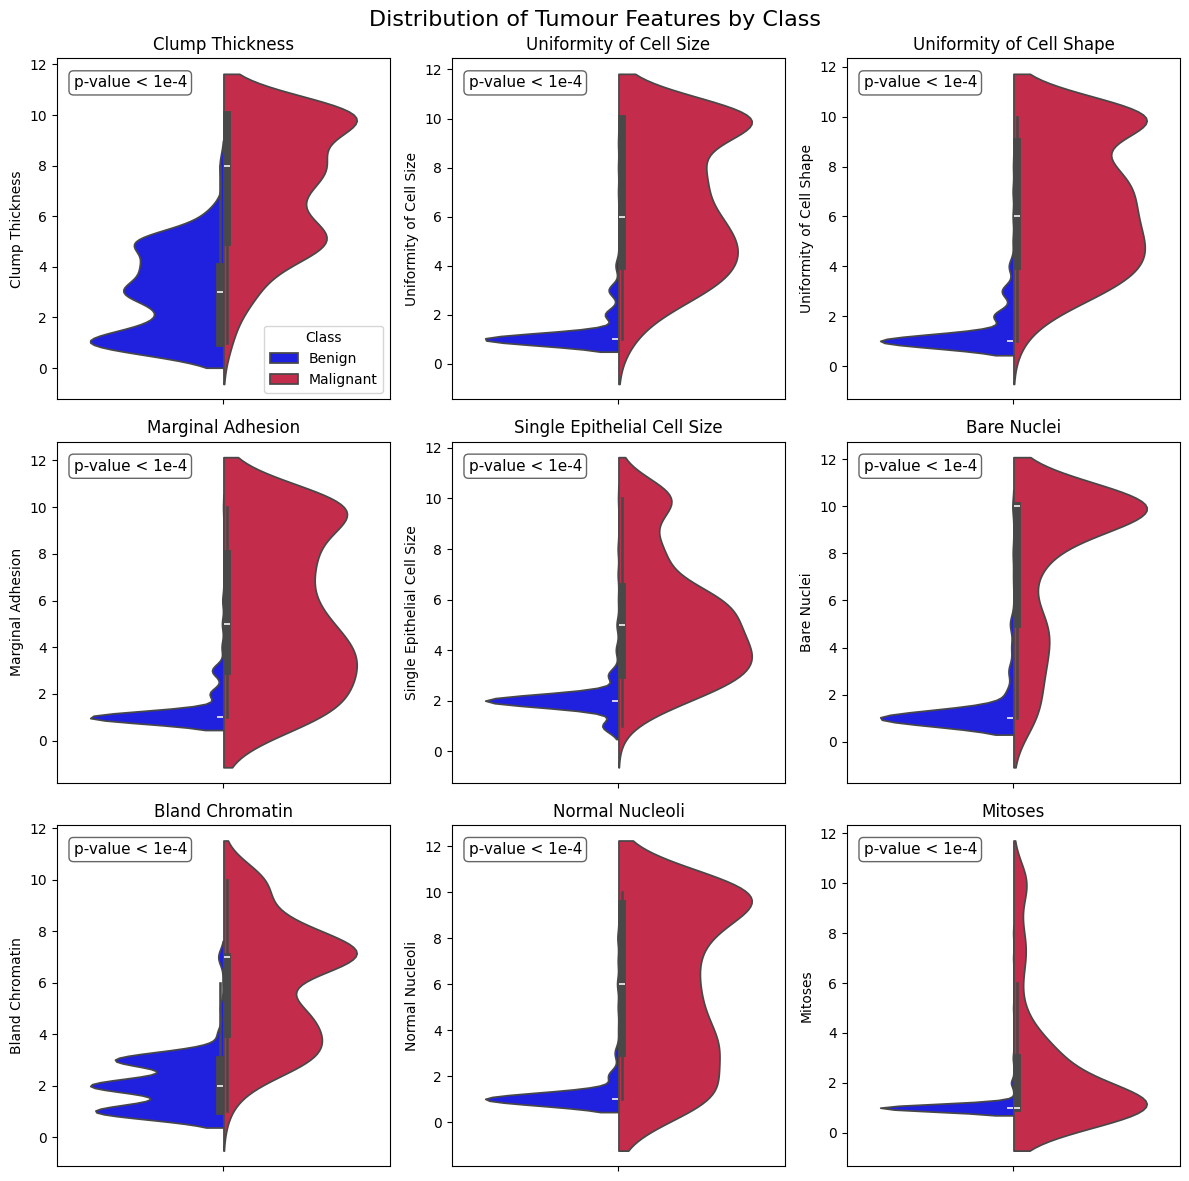

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

features = list(df1)[1:-1]

plt.figure(figsize=(12, 12))

counter = 0

# Pre-split once
benign = df1[df1["Class"] == "Benign"]
malignant = df1[df1["Class"] == "Malignant"]

for i in features:
    counter += 1
    ax = plt.subplot(3, 3, counter)
    
    sns.violinplot(
        data=df1,
        y=i,
        hue="Class",
        split=True,
        palette={"Benign": "blue", "Malignant": "crimson"},
        ax=ax
    )
    
    # Keep legend only in first subplot
    if counter != 1:
        ax.get_legend().remove()
    
    # Drop NaNs
    bx = benign[i].dropna()
    mx = malignant[i].dropna()
    
    # Compute p-value
    try:
        _, p_val = stats.mannwhitneyu(bx, mx, alternative='two-sided')
    except ValueError:
        p_val = np.nan
    
    # Format p-value
    if np.isnan(p_val):
        p_text = "p-value = nan"
    elif p_val < 1e-4:
        p_text = "p-value < 1e-4"
    else:
        p_text = f"p-value = {p_val:.4f}"
    
    # Titles
    ax.set_title(i)
    
    # Add p-value annotation
    ax.text(
        0.05, 0.95,
        p_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
    )

plt.suptitle("Distribution of Tumour Features by Class", fontsize=16)
plt.tight_layout()
plt.show()

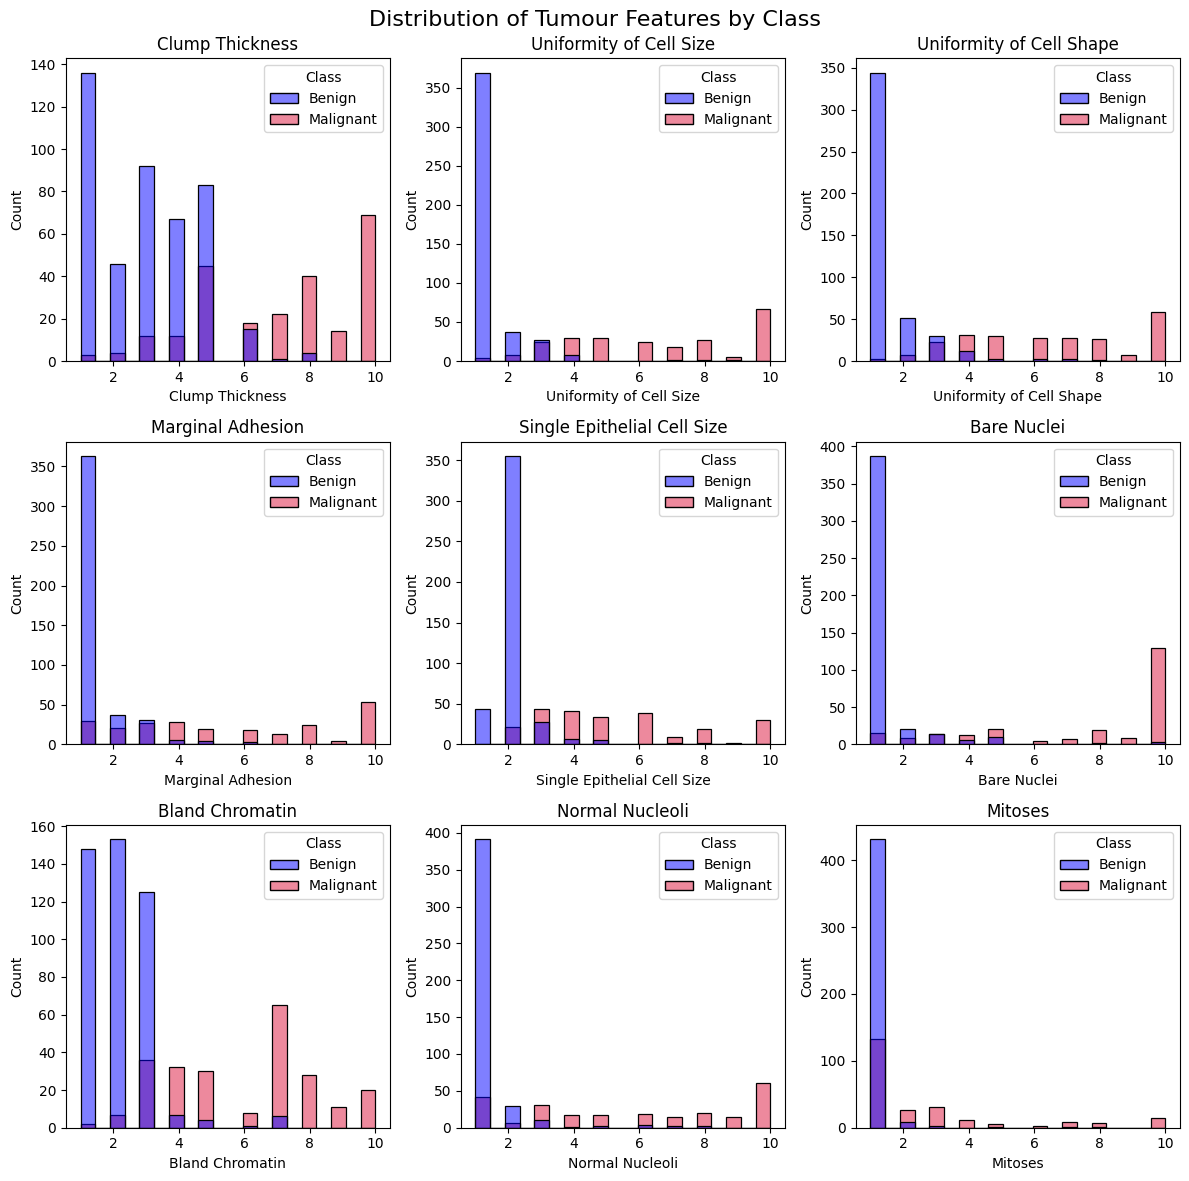

In [6]:
features = list(df1)[1:-1]

plt.figure(figsize=(12,12))

counter = 0
for i in features:
    counter += 1
    plt.subplot(3,3,counter)
    sns.histplot(
        df1,
        x=i,
        hue="Class",
        bins=20,
        palette={"Benign": "blue", "Malignant": "crimson"}  
    )
    plt.title(i)

plt.suptitle("Distribution of Tumour Features by Class", fontsize=16)
plt.tight_layout()  #
plt.show()

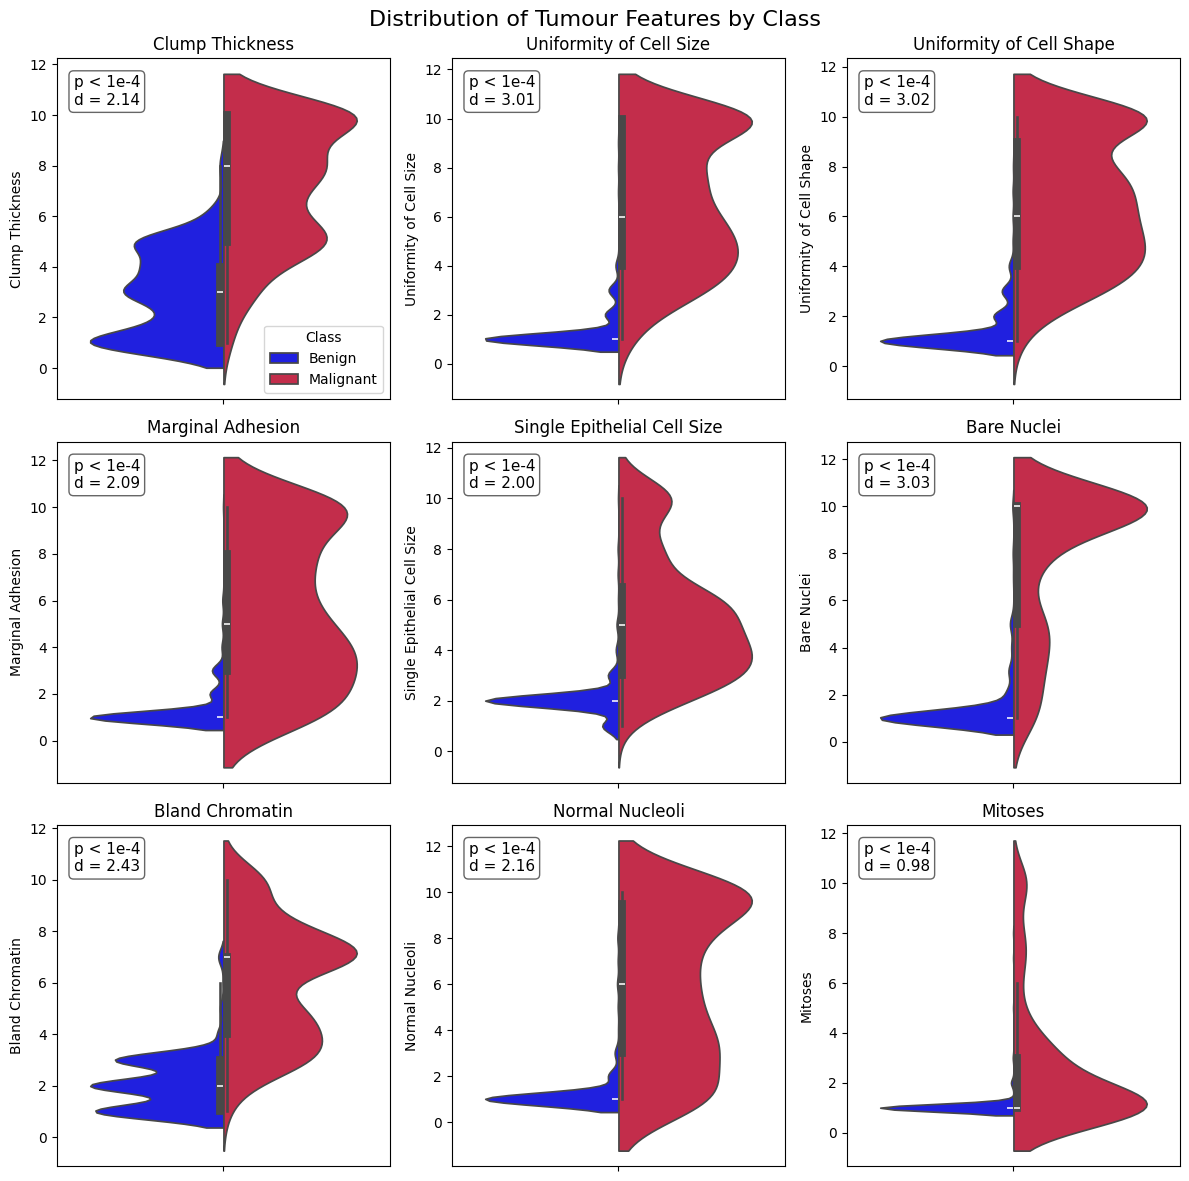

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Effect size function ---
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2)
    )
    if pooled_std == 0:
        return np.nan
    return abs(np.mean(x) - np.mean(y)) / pooled_std


features = list(df1)[1:-1]

plt.figure(figsize=(12, 12))

counter = 0

# Pre-split once
benign = df1[df1["Class"] == "Benign"]
malignant = df1[df1["Class"] == "Malignant"]

for i in features:
    counter += 1
    ax = plt.subplot(3, 3, counter)
    
    sns.violinplot(
        data=df1,
        y=i,
        hue="Class",
        split=True,
        palette={"Benign": "blue", "Malignant": "crimson"},
        ax=ax
    )
    
    # Keep legend only in first subplot
    if counter != 1:
        ax.get_legend().remove()
    
    # Drop NaNs
    bx = benign[i].dropna()
    mx = malignant[i].dropna()
    
    # --- p-value ---
    try:
        _, p_val = stats.mannwhitneyu(bx, mx, alternative='two-sided')
    except ValueError:
        p_val = np.nan
    
    # --- Cohen's d ---
    d_val = cohens_d(bx.values, mx.values)
    
    # Format p-value
    if np.isnan(p_val):
        p_text = "p = nan"
    elif p_val < 1e-4:
        p_text = "p < 1e-4"
    else:
        p_text = f"p = {p_val:.4f}"
    
    # Format Cohen's d
    if np.isnan(d_val):
        d_text = "d = nan"
    else:
        d_text = f"d = {d_val:.2f}"
    
    # Titles
    ax.set_title(i)
    
    # Annotation block
    ax.text(
        0.05, 0.95,
        f"{p_text}\n{d_text}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
    )

plt.suptitle("Distribution of Tumour Features by Class", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
df1

,Sample number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1,5,1,1,1,2,1.0,3,1,1,Benign
1,2,5,4,4,5,7,10.0,3,2,1,Benign
2,3,3,1,1,1,2,2.0,3,1,1,Benign
3,4,6,8,8,1,3,4.0,3,7,1,Benign
4,5,4,1,1,3,2,1.0,3,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
678,679,3,1,1,1,3,2.0,1,1,1,Benign
679,680,2,1,1,1,2,1.0,1,1,1,Benign
680,681,5,10,10,3,7,3.0,8,10,2,Malignant
681,682,4,8,6,4,3,4.0,10,6,1,Malignant


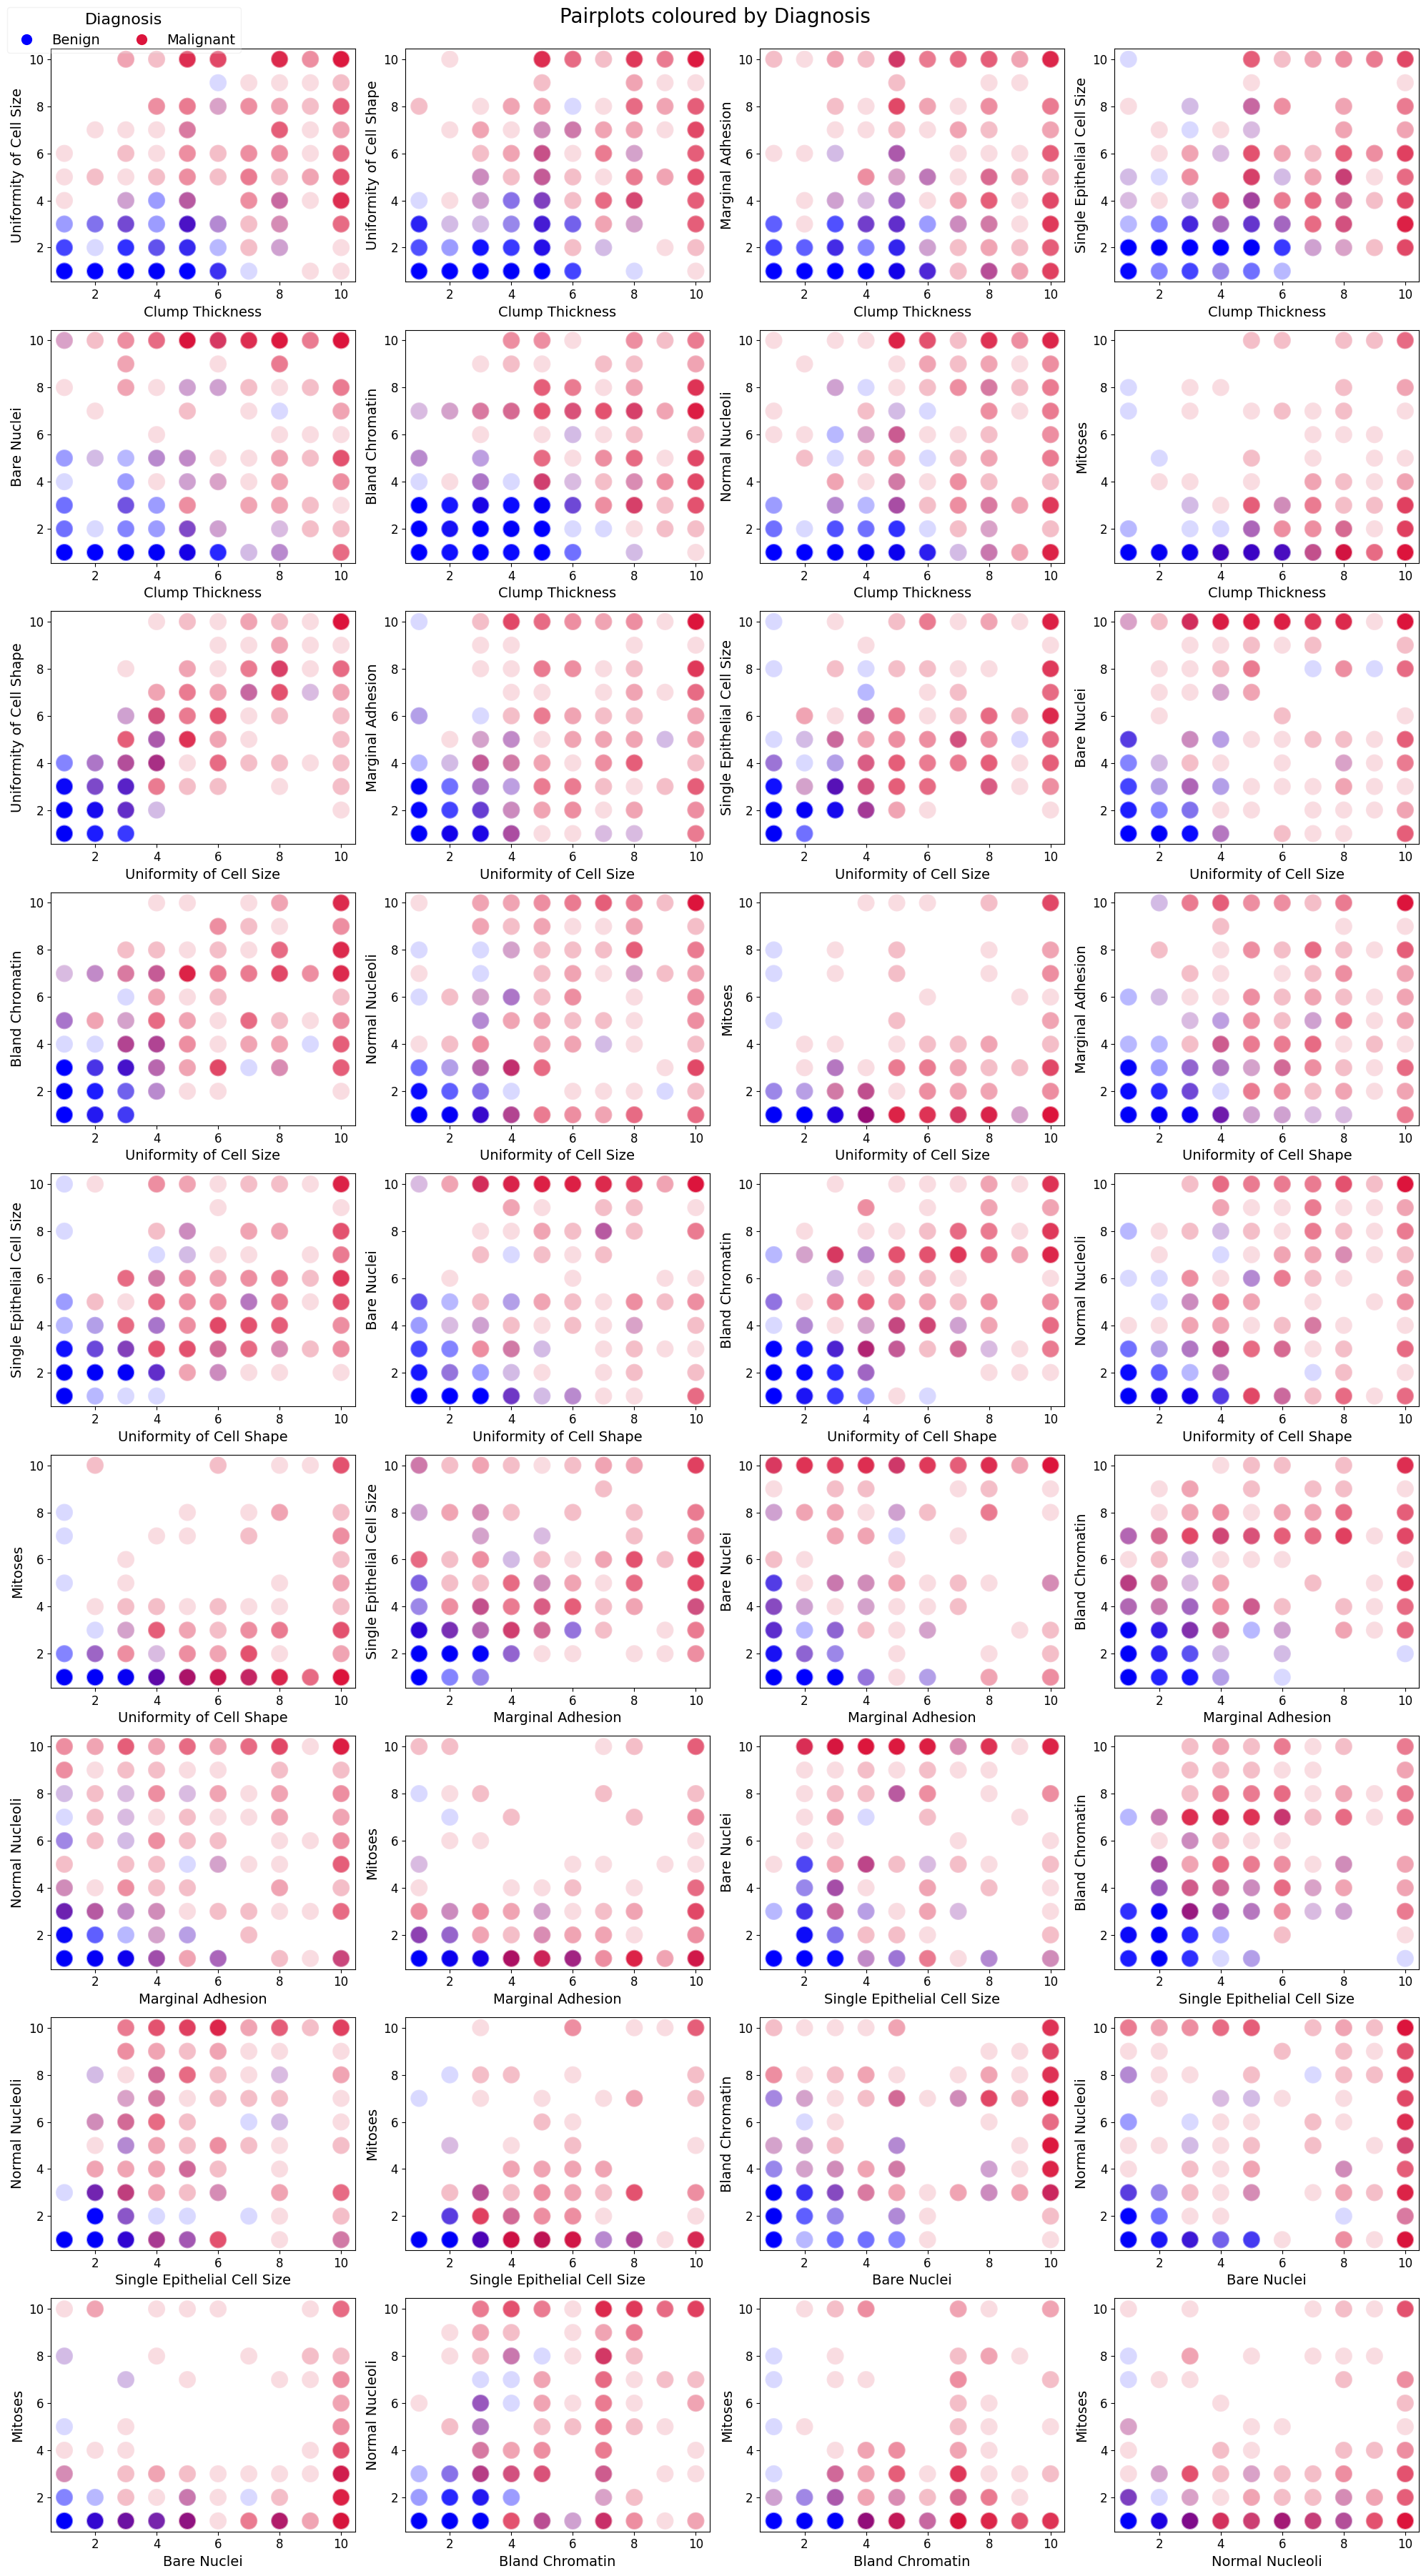

In [8]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
data=df1.copy()
# numeric columns
cols = data.select_dtypes(include="number").columns.drop("Sample number")

# unique pairs
pairs = list(itertools.combinations(cols, 2))

n = len(pairs)
ncols = 4
nrows = (n + ncols - 1) // ncols

# 🎨 custom palette
palette = {
    "Benign": "blue",
    "Malignant": "crimson"
}

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
fig.suptitle("Pairplots coloured by Diagnosis",fontsize=20, x=0.5, y=1.)
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(
        data=data,
        x=x,
        y=y,
        hue="Class",
        palette=palette,
        s=300,
        alpha=0.15,
        ax=ax,
        legend=False
    )
    
    # 🔤 increase axis label size
    ax.set_xlabel(x, fontsize=14)
    ax.set_ylabel(y, fontsize=14)
    
    # 🔢 increase tick size
    ax.tick_params(axis='both', labelsize=12)

# remove empty subplots
for ax in axes[len(pairs):]:
    ax.remove()

# ✅ larger legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Benign',
           markerfacecolor='blue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Malignant',
           markerfacecolor='crimson', markersize=12)
]

fig.legend(
    handles=legend_elements,
    loc='upper left',
    title='Diagnosis',
    title_fontsize=16,
    fontsize=14,
    framealpha=0.25,
    ncols=2
)

plt.tight_layout()


### Conclusion:
1. There is no linear relation between the categorical features;
2. There is a clear tumour class separation

In [12]:
X0=df1[["Clump Thickness","Uniformity of Cell Size","Uniformity of Cell Shape"]].to_numpy()
y0=df1.Class.to_numpy()

In [16]:
Dict={"Benign":"blue","Malignant":"crimson"}

In [123]:
plot_3d_plotly(X0,y0,title="3D scatter plot (Clump Thickness, Uniformity of Cell Size and Uniformity of Cell Shape)",color_map=Dict,)

# EXTRA: Data Dimensionality Reduction and Visualization:
Here, we test the data visualization through different data dimensionality reduction methods:

1. PCA;
2. Isomap;
3. t-SNE:
4. UMAP

**WARNING:** Make sure you have sklearn and umap libraries installed.

In [102]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from umap import UMAP

In [103]:
X=df1[list(df1)[:-1]].to_numpy()
y=df1.Class.to_numpy()

# PCA:

In [112]:
P=PCA( n_components=3)
P0=P.fit_transform(X)

In [118]:
plot_3d_plotly(P0,y,title="3D Plot with PCA",color_map=Dict)

# Isomap:

In [106]:
I=Isomap(n_neighbors=15,metric="euclidean",n_components=3)
I0=I.fit_transform(X)

In [115]:
plot_3d_plotly(I0,y,title="3D Plot with Isomap",color_map=Dict)


# t-SNE:

In [108]:
T=TSNE(perplexity=15 ,n_components=3)
T0=T.fit_transform(X)

In [116]:
plot_3d_plotly(T0,y,title="3D Plot with t-SNE",color_map=Dict)

# UMAP

In [110]:
U=UMAP(n_neighbors=15,min_dist=0.1,metric="cosine",n_components=3)
U0=U.fit_transform(X)

In [117]:
plot_3d_plotly(U0,y,title="3D Plot with UMAP",color_map=Dict)

# Conclusion:
1. Overall, there is a clear tumour class separability from tumour features;
2. There is no linear relation between the tumour features;
3.  There is no need to use all the features to obtain an evident separability;
4.  High linear correlation between Uniformity of Cell Size, Uniformity of Cell Shape, Bland Chromatin, Normal Nucleoli, Single Epithelial Cell Size, and Bare Nuclei;
5.  Best metrics: Shape, Size and thickness;
6.  Best cost/benefit dimensionality reduction method for 3D visualisation (in this case): PCA